<a href="https://colab.research.google.com/github/LinearAlgebruh/PredictingMarchMadness/blob/main/GradientBoostingPython.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import torch
!pip install pyreadr
import pyreadr

class Node:

 def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature   = feature
        self.threshold = threshold
        self.left      = left
        self.right     = right
        self.value     = value

class RegressionTree:

  def __init__(self, max_depth=3, min_samples_split=2):
        self.max_depth         = max_depth
        self.min_samples_split = min_samples_split
        self.root              = None

  def fit(self, X, y):
        self.root = self._build(X, y)

  def _build(self, X, y, depth=0):
        n, p = X.shape

        # Stopping Conditions
        if depth >= self.max_depth or len(y) < self.min_samples_split or torch.var(y) == 0:
            return Node(value=torch.mean(y))

        feature, threshold = self._best_split(X, y)
        if feature is None:
            return Node(value=torch.mean(y))

        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask

        return Node(
            feature=feature,
            threshold=threshold,
            left=self._build(X[left_mask], y[left_mask], depth + 1),
            right=self._build(X[right_mask], y[right_mask], depth + 1),
        )


  def _best_split(self, X, y):
        best_loss   = float("inf")
        best_feat   = None
        best_thresh = None
        n, p = X.shape

        for feat in range(p):
            thresholds = torch.unique(X[:, feat])
            for thresh in thresholds:
                left = y[X[:, feat] <= thresh]
                right = y[X[:, feat] > thresh]
                if len(left) == 0 or len(right) == 0:
                    continue
                loss = self._weighted_mse(left, right)
                if loss < best_loss:
                    best_loss   = loss
                    best_feat   = feat
                    best_thresh = thresh

        return best_feat, best_thresh

  def _weighted_mse(self, left, right):
        n = len(left) + len(right)
        return (len(left) * torch.var(left, correction = 0) + len(right) * torch.var(right, correction = 0)) / n

  def predict(self, X):
        return torch.tensor([self._traverse(x, self.root) for x in X])

  def _traverse(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self._traverse(x, node.left)
        return self._traverse(x, node.right)



class GradientBoostedTrees:
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3, min_samples_split=2):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.trees = []
        self.F0 = None

    def _sigmoid(self, x):
        return torch.sigmoid(x)

    def _negative_gradient(self, y, F):
        return y - self._sigmoid(F)

    def _loss(self, y, F):
        p = self._sigmoid(F)
        return -torch.mean(y * torch.log(p) + (1 - y) * torch.log(1 - p))

    def fit(self, X, y):
        p = torch.mean(y)

        self.F0 = torch.log(p / (1 - p))

        F = torch.full((len(y),), self.F0.item())

        for m in range(self.n_estimators):
            residuals = self._negative_gradient(y, F)

            tree = RegressionTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split
            )
            tree.fit(X, residuals)

            update = tree.predict(X)
            F = F + self.learning_rate * update
            self.trees.append(tree)

    def predict_raw(self, X):
        F = torch.full((X.shape[0],), self.F0.item())
        for tree in self.trees:
            F = F + self.learning_rate * tree.predict(X)
        return F

    def predict(self, X):
        F = self.predict_raw(X)
        return (self._sigmoid(F) >= 0.5).int()

    def predict_proba(self, X):
        return self._sigmoid(self.predict_raw(X))

In [3]:
# Data Prep Methods
def readRSD(url, scratch):
  '''
  Reads in an RSD file from url and returns a dataframe.
  Scratch should be in ./_______.rda format.
  '''
  local = pyreadr.download_file(url, scratch)
  result = pyreadr.read_r(local)
  df = result[None]
  return df

def get_team_stats(df, team_id, year):
    """
    Returns all stats for a given team from a Detailed Results DataFrame,
    normalized to team/opponent perspective (instead of winner/loser).

    Parameters:
        df      : Detailed Results DataFrame
        team_id : The team's ID to filter by
        year    : (optional) Season year to filter by. If None, returns all years.

    Returns:
        DataFrame with one row per game, stats from the team's perspective
    """

    stat_cols = ['FGM', 'FGA', 'FGM3', 'FGA3', 'FTM', 'FTA',
                 'OR', 'DR', 'Ast', 'TO', 'Stl', 'Blk', 'PF']


    won = df[(df['WTeamID'] == team_id) & (df['Season'] == year)].copy()
    lost = df[(df['LTeamID'] == team_id) & (df['Season'] == year)].copy()

    # Games where team won
    won['TeamID']      = won['WTeamID']
    won['OpponentID']  = won['LTeamID']
    won['TeamScore']   = won['WScore']
    won['OppScore']    = won['LScore']
    won['Result']      = 1
    for col in stat_cols:
        won[col]           = won[f'W{col}']
        won[f'Opp{col}']   = won[f'L{col}']

    # Games where team lost
    lost['TeamID']     = lost['LTeamID']
    lost['OpponentID'] = lost['WTeamID']
    lost['TeamScore']  = lost['LScore']
    lost['OppScore']   = lost['WScore']
    lost['Result']     = 0
    for col in stat_cols:
        lost[col]          = lost[f'L{col}']
        lost[f'Opp{col}']  = lost[f'W{col}']

    # --- Combine and select final columns ---
    keep_cols = ['Season', 'DayNum', 'TeamID', 'OpponentID', 'TeamScore',
                 'OppScore', 'Result', 'NumOT'] + \
                stat_cols + [f'Opp{col}' for col in stat_cols]

    team_games = pd.concat([won, lost])[keep_cols]

    team_games = team_games.astype(float)

    team_games = team_games.sort_values(['Season', 'DayNum']).reset_index(drop=True)

    team_games = pd.concat([team_games, team_games.mean(axis=0).to_frame().T], ignore_index=True)


    return team_games

def get_tensor(df):
  '''
  Takes boxscore df  for a team over a season as input and returns a
  single tensor containing their season aggregated stats.
  '''
  df = df.drop(columns=['Season', 'DayNum', 'TeamID', 'OpponentID'])
  # convert to a NumPy array first
  stat_tensor = torch.tensor(df.iloc[-1].to_numpy(), dtype=torch.float32)
  return stat_tensor



# Get all results from 2003 onwards
def get_all_results(outcomes):
  '''
  Scrapes all game outcomes from df and returns a boolean vector of game outcomes.
  This method gives us our prediction targets. A value of 1 corresponds to the
  team with lower team ID winning and 0 to the team with higher team ID.
  Note that seeds are not a factor in determining 0 or 1, so this has nothing
  to do with seeding.
  '''
  outcomes = outcomes[outcomes['Season'] >= 2003] # Only have box score stats from 2003 onwards
  results = []
  for i in range(len(outcomes)):

    if outcomes.iloc[i]['WTeamID'] < outcomes.iloc[i]['LTeamID']:
      results.append(1)
    else:
      results.append(0)

  results = torch.tensor(results)
  return results


def gather_team_stats(outcomes,box_scores):
  '''
  Takes outcomes, a df containing each MM game's winner and loser, alongside
  box_scores, a df containing the box scores for all games from 2003 onwards,
  and combines them into a tensor where each row contains all season stats
  for two teams in the tournament. This method returns the X tensor we need
  for ML methods.
  '''
  outcomes = outcomes[outcomes['Season'] >= 2003]
  feature_list = []
  for i in range(len(outcomes)):

    team1 = min(outcomes['WTeamID'].iloc[i], outcomes['LTeamID'].iloc[i])
    team2 = max(outcomes['WTeamID'].iloc[i], outcomes['LTeamID'].iloc[i])

    df1 = get_team_stats(box_scores, team1, outcomes['Season'].iloc[i])
    df2 = get_team_stats(box_scores, team2, outcomes['Season'].iloc[i])

    tens1 = get_tensor(df1)
    tens2 = get_tensor(df2)
    tens = torch.cat([tens1, tens2], dim=0)
    feature_list.append(tens)

  return torch.stack(feature_list)

# Read Files
outcomes = readRSD('https://github.com/kim3-sudo/march_madness_data/raw/refs/heads/main/DataFiles/NCAATourneyCompactResults.rds', './TourneyResults.rda')
box_scores = readRSD('https://github.com/kim3-sudo/march_madness_data/raw/refs/heads/main/Prelim2019_RegularSeasonDetailedResults.rds', './DetailedStats.rda')

# Assemble Data
X = gather_team_stats(outcomes, box_scores)
y = get_all_results(outcomes)



In [17]:
def train_gbdt(
    X, y,
    n_estimators=200,
    learning_rate=0.5,
    max_depth=3,
    val_size=0.2,
    patience=10,          # early stopping: stop if no improvement for this many rounds
    min_delta=1e-4,       # minimum improvement to count as progress
    verbose=True,
    log_every=10,
):
    # --- convert to tensors ---
    if not isinstance(X, torch.Tensor):
        X = torch.tensor(X, dtype=torch.float32)
    if not isinstance(y, torch.Tensor):
        y = torch.tensor(y, dtype=torch.float32)

    # --- train/val split ---
    n = len(y)
    n_val = int(n * val_size)
    idx = torch.randperm(n)
    train_idx, val_idx = idx[n_val:], idx[:n_val]

    X_train, y_train = X[train_idx], y[train_idx]
    X_val,   y_val   = X[val_idx],   y[val_idx]

    # --- initialize model ---
    model = GradientBoostedTrees(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
    )

    # --- initialize F ---
    p = torch.clamp(torch.mean(y_train), 1e-6, 1 - 1e-6)
    model.F0 = torch.log(p / (1 - p))


    F_train = torch.full((len(y_train),), model.F0.item())
    F_val   = torch.full((len(y_val),),   model.F0.item())

    # --- tracking ---
    train_losses = []
    val_losses   = []
    best_val_loss = float("inf")
    best_trees    = []
    rounds_without_improvement = 0

    # --- boosting loop ---
    for m in range(n_estimators):

        # compute residuals on train only
        residuals = model._negative_gradient(y_train, F_train)

        # fit tree to residuals
        tree = RegressionTree(max_depth=max_depth)
        tree.fit(X_train, residuals)

        # update train and val predictions
        F_train = F_train + learning_rate * tree.predict(X_train)
        F_val   = F_val   + learning_rate * tree.predict(X_val)

        model.trees.append(tree)

        # compute losses
        train_loss = model._loss(y_train, F_train).item()
        val_loss   = model._loss(y_val,   F_val).item()
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # early stopping check
        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_trees    = list(model.trees)  # snapshot best ensemble
            rounds_without_improvement = 0
        else:
            rounds_without_improvement += 1

        if verbose and (m + 1) % log_every == 0:
            print(f"Round {m+1:4d} | train loss: {train_loss:.4f} | val loss: {val_loss:.4f} | no improvement: {rounds_without_improvement}/{patience}")

        if rounds_without_improvement >= patience:
            if verbose:
                print(f"\nEarly stopping at round {m+1}. Best val loss: {best_val_loss:.4f}")
            break

    # restore best ensemble
    model.trees = best_trees

    return model, train_losses, val_losses

Round   10 | train loss: 0.6686 | val loss: 0.6852 | no improvement: 0/15


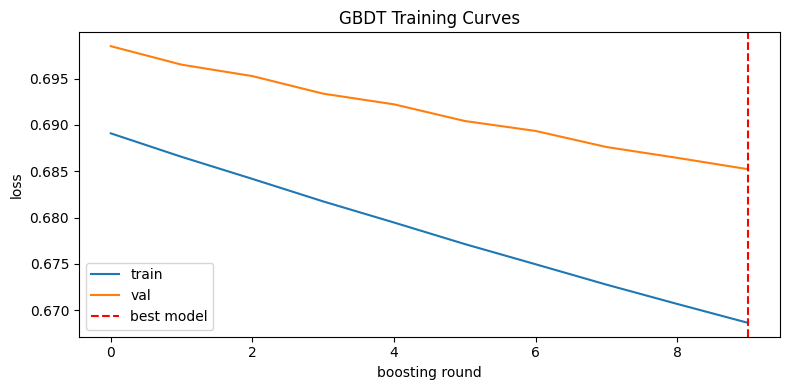

In [18]:
import matplotlib.pyplot as plt

def plot_losses(train_losses, val_losses):
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label="train")
    plt.plot(val_losses,   label="val")
    plt.axvline(len(val_losses) - 1, color="red", linestyle="--", label="best model")
    plt.xlabel("boosting round")
    plt.ylabel("loss")
    plt.title("GBDT Training Curves")
    plt.legend()
    plt.tight_layout()
    plt.show()

y = y.float()

model, train_losses, val_losses = train_gbdt(
    X, y,
    n_estimators=10,
    learning_rate=0.05,
    max_depth=3,
    patience=15,
    log_every=10,
)

plot_losses(train_losses, val_losses)

In [25]:
from sklearn.metrics import accuracy_score

preds = model.predict(X)
accuracy_score(preds, y)

# print(torch.mean((preds == y).float()))

0.6240458015267175